# 15. Technology taxonomy: learning a business class from procurement text

BOAMP publishes an administrative vocabulary — CPV divisions, BOAMP
"descripteurs" — not the business-oriented technology class this study needs. The
cohort is defined by CPV divisions `32`, `35`, `48` and `72`, which is
reproducible and auditable but coarse: it says a procurement is *digital* without
saying what was bought.

This notebook builds and evaluates the classifier that supplies the missing
variable:

```text
procurement object text  ->  supervised classifier  ->  business technology class
```

**What this notebook does and does not do.** It *runs* the corpus construction and
the full grouped cross-validation — every model number below is computed while you
watch, not read from a file. It *loads* the deployed classifier rather than
refitting it, so what is inspected in section 9 is exactly the model that scored
the 3,800 cohort episodes.

**What it does not touch.** The linkage, survival, and trend results are frozen.
The taxonomy is an enrichment layer over them; CPV remains the cohort definition,
the Cox covariate, and the trend series.

### Notation

| Symbol | Meaning |
|---|---|
| $X_i$ | the object text (`objet`) of annotated notice $i$ |
| $Y_i \in \mathcal{Y}$ | its manually annotated technology class, $|\mathcal{Y}| = 11$ |
| $g(i)$ | the *procurement family* of notice $i$ — the leakage unit |
| $f: X \mapsto \mathcal{Y}$ | the learned classifier |
| $\hat{p}_k(x)$ | calibrated probability that $x$ belongs to class $k$ |
| $e$ | a procurement episode in the study cohort |
| $\text{objet}(e)$ | the object text of $e$'s origin notice, the deployment input |

Macro-F1 — the unweighted mean of per-class F1 — is the headline throughout,
because the classes are imbalanced and accuracy would be dominated by the three
largest.

## 1. Reproducible setup

Everything is imported from `boamp_pipeline`, so the code shown here is the code the pipeline runs.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "boamp_pipeline").is_dir():
            return candidate
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

TECHNOLOGY = PROJECT_ROOT / "data" / "processed" / "boamp" / "technology"

# Categorical slots 1-4 of the reference palette, matching notebooks 13 and 14.
INK, ACCENT, GREEN, RUST = "#356E9A", "#C28A24", "#3F8F6B", "#9A4F35"
GRID = "#E1E5E8"
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)


def table(name: str) -> pd.DataFrame:
    return pd.read_csv(TECHNOLOGY / name)


def load_json(name: str) -> dict:
    return json.loads((TECHNOLOGY / name).read_text(encoding="utf-8"))

In [2]:
from boamp_pipeline.technology_taxonomy import (
    CLASS_ORDER,
    MIN_RELIABLE_SUPPORT,
    NEAR_DUPLICATE_THRESHOLD,
    N_SPLITS,
    RANDOM_SEED,
    SUBSTANTIVE_CLASSES,
    build_corpus,
    build_group_ids,
    normalize_objet,
    text_pipeline,
)
from boamp_pipeline.technology_models import (
    CONFIDENCE_CUTOFF,
    comparison_table,
    load_corpus_and_folds,
    run_all_specifications,
    specifications,
)

# scripts/build_survival_evidence.py forces the Agg backend when imported, and
# the evidence module reuses its conditional_probability. Restore inline so the
# figures below render here rather than being written to nowhere.
%matplotlib inline

print("substantive classes:", len(SUBSTANTIVE_CLASSES))
print("fallback classes   :", [c for c in CLASS_ORDER if c not in SUBSTANTIVE_CLASSES])
print(f"folds={N_SPLITS}  seed={RANDOM_SEED}  near-duplicate threshold={NEAR_DUPLICATE_THRESHOLD}")

substantive classes: 8
fallback classes   : ['MIXED', 'OTHER_DIGITAL', 'OTHER']
folds=3  seed=20260819  near-duplicate threshold=0.8


## 2. The annotated corpus

500 manually annotated BOAMP notices, 2015–2025. This is the only ground truth the
project has for the business taxonomy. It is read from the delivered file rather
than described, so anything below that contradicts the file is a bug.

In [3]:
corpus, near_duplicates = build_corpus()
audit = load_json("annotation_audit_summary.json")

print(f"rows {len(corpus)}  unique idweb {corpus['idweb'].nunique()}  "
      f"years {int(corpus['year'].min())}-{int(corpus['year'].max())}")
print(f"missing label {(corpus['label'].str.strip() == '').sum()}  "
      f"missing objet {(corpus['text'].str.strip() == '').sum()}")
print(f"objet words: median {int(corpus['text_word_count'].median())}, "
      f"p95 {int(corpus['text_word_count'].quantile(0.95))}, "
      f"max {int(corpus['text_word_count'].max())}")
corpus[["idweb", "year", "label", "objet"]].head(4)

rows 500  unique idweb 500  years 2015-2025
missing label 0  missing objet 0
objet words: median 14, p95 27, max 33


,idweb,year,label,objet
0,19-95263,2019,IT_SERVICES,fourniture d'une infrastructure on remise et infogerance
1,20-103489,2020,OTHER,Fourniture de vêtements de travail destinés aux agents du Grand Port Maritime de Rouen
2,19-84495,2019,CLOUD_HOSTING,Hébergement de sites et services internet et prestations associees pour le département...
3,15-115096,2015,NETWORK_TELECOM,"fourniture de service d'adduction réseau pour les sites à Saint Malo, à Paimpont, à Fo..."


### Class distribution, and why it is not a market share

The counts below are a property of the **annotation design**, not of the
population. `BUSINESS_SOFTWARE` appears almost exactly eight times per year and
`NETWORK_TELECOM` eight to nine: the sample was drawn to quotas by class and year.
Nothing downstream may read these proportions as prevalence.

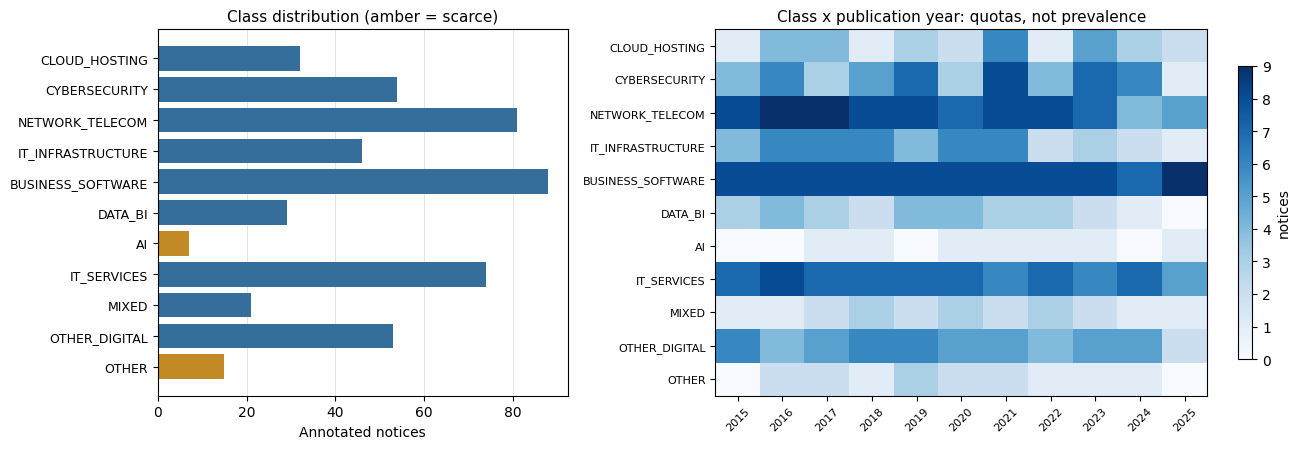

AI: 7 notices across 11 years. No synthetic examples were generated and no oversampling was applied.


In [4]:
counts = corpus["label"].value_counts().reindex(list(CLASS_ORDER))
by_year = pd.crosstab(corpus["label"], corpus["year"]).reindex(list(CLASS_ORDER))

figure, (left, right) = plt.subplots(1, 2, figsize=(13.5, 4.6),
                                     gridspec_kw={"width_ratios": [1, 1.5]})
colours = [ACCENT if c < MIN_RELIABLE_SUPPORT * 2 else INK for c in counts]
left.barh(range(len(counts)), counts.values, color=colours)
left.set_yticks(range(len(counts)))
left.set_yticklabels(counts.index, fontsize=9)
left.invert_yaxis()
left.set_xlabel("Annotated notices")
left.set_title("Class distribution (amber = scarce)", fontsize=11)
left.grid(axis="x", color=GRID, linewidth=0.7)
left.set_axisbelow(True)

image = right.imshow(by_year.values, cmap="Blues", aspect="auto")
right.set_xticks(range(by_year.shape[1]))
right.set_xticklabels(by_year.columns, rotation=45, fontsize=8)
right.set_yticks(range(len(by_year)))
right.set_yticklabels(by_year.index, fontsize=8)
right.set_title("Class x publication year: quotas, not prevalence", fontsize=11)
figure.colorbar(image, ax=right, shrink=0.8, label="notices")
figure.tight_layout()
plt.show()

print(f"AI: {counts['AI']} notices across 11 years. No synthetic examples were "
      "generated and no oversampling was applied.")

## 3. Leakage prevention — the step that decides whether anything below is real

BOAMP republishes one procurement many times (tender, corrections, award), and
buyers re-run the same tender years later with almost the same wording. A model
scored on a near-copy of a document it trained on measures memorisation.

Every labelled notice is assigned to a **procurement family** $g(i)$, the union of
two rules:

1. notices the canonical episode reconstruction already placed in one episode;
2. notices whose `objet` reaches character cosine $\geq 0.80$.

Rule 2 is not optional. Rule 1 alone leaves near-identical notices in *different*
episodes free to land in different folds.

In [5]:
# The grouping runs here, on the same inputs the pipeline uses.
groups, pairs = build_group_ids(
    corpus["idweb"].tolist(),
    corpus["episode_id"].tolist(),
    corpus["objet"].tolist(),
    NEAR_DUPLICATE_THRESHOLD,
)
sizes = pd.Series(groups).value_counts()

episodes_only = corpus.loc[corpus["episode_id"] != "", "episode_id"].nunique()
across = sum(1 for a, b, _ in pairs
             if corpus["episode_id"].iloc[a] != corpus["episode_id"].iloc[b])

print(f"rule 1 alone (episode id)      : {episodes_only} groups")
print(f"rule 2 merges                  : {len(pairs)} near-duplicate pairs")
print(f"  of which in DIFFERENT episodes: {across}  <- these would have leaked")
print(f"final procurement families     : {len(sizes)} "
      f"({(sizes == 1).sum()} singletons, {(sizes > 1).sum()} multi-notice, "
      f"largest {sizes.max()})")

rule 1 alone (episode id)      : 486 groups
rule 2 merges                  : 39 near-duplicate pairs
  of which in DIFFERENT episodes: 29  <- these would have leaked
final procurement families     : 459 (423 singletons, 36 multi-notice, largest 3)


### What rule 2 actually caught

Same buyer, same wording, four years apart, two different episodes — and in three
families, two different labels. Those label conflicts are **not corrected**: there
is no evidence deciding which reading is right, and editing labels after seeing
model errors fits the corpus to its classifier. They are an empirical floor on
attainable accuracy.

In [6]:
shown = pd.DataFrame([
    {
        "similarity": round(score, 3),
        "same_episode": corpus["episode_id"].iloc[a] == corpus["episode_id"].iloc[b],
        "label_a": corpus["label"].iloc[a],
        "label_b": corpus["label"].iloc[b],
        "conflict": corpus["label"].iloc[a] != corpus["label"].iloc[b],
        "objet_a": corpus["objet"].iloc[a][:64],
        "objet_b": corpus["objet"].iloc[b][:64],
    }
    for a, b, score in sorted(pairs, key=lambda p: -p[2])
])
print(f"{int(shown['conflict'].sum())} of {len(shown)} merged pairs carry conflicting labels\n")
display(shown.loc[shown["conflict"]])
display(shown.loc[~shown["conflict"]].head(6))

4 of 39 merged pairs carry conflicting labels



,similarity,same_episode,label_a,label_b,conflict,objet_a,objet_b
11,0.947,False,IT_INFRASTRUCTURE,IT_SERVICES,True,"Fourniture, mise en oeuvre et infogérance d'une infrastructure s","Fourniture, mise en oeuvre et infogérance d'une nouvelle infrast"
18,0.920,False,OTHER_DIGITAL,NETWORK_TELECOM,True,2021-12_VISIO_PRESTATION DE SERVICES MANAGES DE VISIOCONFERENCE,2017-08_VISIO PRESTATION DE SERVICES MANAGES DE VISIOCONFERENCE
20,0.912,False,MIXED,CLOUD_HOSTING,True,Fourniture d'accès réseau sécurisés et d'une infrastructure as a,Fourniture d'accès réseau sécuriséset d'une Infrastructure as a
21,0.910,False,IT_SERVICES,IT_INFRASTRUCTURE,True,"Fourniture, mise en oeuvre et infogérance d'une nouvelle infrast","Fourniture, mise en uvre et infogérance d'une infrastructure se"


,similarity,same_episode,label_a,label_b,conflict,objet_a,objet_b
0,1.000,True,MIXED,MIXED,False,"Fourniture, intégration et garantie d'équipements informatiques","2019DSN297 Fourniture, intégration et garantie d'équipements inf"
1,0.992,False,BUSINESS_SOFTWARE,BUSINESS_SOFTWARE,False,"MAINTENANCE CORRECTIVE, ADAPTATIVE, REGLEMENTAIRE ET EVOLUTIVE D","Maintenance corrective, adaptative, réglementaire, évolutive du"
2,0.971,False,CYBERSECURITY,CYBERSECURITY,False,relance - prestations d'expertises et d'assistance informatique,prestations d'expertises et d'assistance informatique sur leslog
3,0.965,True,IT_SERVICES,IT_SERVICES,False,Assistance à l'élaboration d'une stratégie d'évolution du systèm,Assistance à l'élaboration d'une stratégie d'évolution du systèm
4,0.963,False,CLOUD_HOSTING,CLOUD_HOSTING,False,"Hebergement D'Applications Web, Gestion Des Noms De Domaines Et","hébergement d'applications web, gestion des noms de domaines et"
5,0.961,False,IT_INFRASTRUCTURE,IT_INFRASTRUCTURE,False,"Fourniture, mise en oeuvre et infogérance d'une infrastructure s","Fourniture, mise en uvre et infogérance d'une infrastructure se"


## 4. The frozen folds

Three folds, not five or ten: with 500 notices and `AI` at 7, five folds leave the
rarest class with roughly one held-out observation per fold and its per-fold F1
becomes a coin flip. `StratifiedGroupKFold` keeps every family whole and balances
classes as a secondary objective.

The fold assignment is written to disk once and every model uses it, so no model
can be advantaged by a friendlier split.

In [7]:
corpus_frozen, fold_index = load_corpus_and_folds()
folds = table("nlp_cv_folds.csv")

# The families built live above must reproduce the frozen assignment exactly.
assert list(corpus_frozen["idweb"]) == list(corpus["idweb"])
assert (corpus_frozen["group_id"].to_numpy() == np.array(groups)).all()
assert folds.groupby("group_id")["fold"].nunique().max() == 1, "a family spans folds"

support = pd.crosstab(folds["label"], folds["fold"]).reindex(list(CLASS_ORDER))
support["total"] = support.sum(axis=1)
print("no family is split across folds; every class appears in every fold\n")
display(support)

no family is split across folds; every class appears in every fold



fold,0,1,2,total
label,,,,
CLOUD_HOSTING,11,11,10,32
CYBERSECURITY,18,18,18,54
NETWORK_TELECOM,27,27,27,81
IT_INFRASTRUCTURE,15,15,16,46
BUSINESS_SOFTWARE,29,30,29,88
DATA_BI,10,10,9,29
AI,2,2,3,7
IT_SERVICES,25,25,24,74
MIXED,7,7,7,21


## 5. What the model is allowed to read

The input is `objet` alone. Normalisation is deliberately light — mojibake repair,
Unicode NFC, lowercasing, whitespace — and **accents are preserved**. The classes
are distinguished by words like `cybersécurité`, `logiciel métier` and
`intelligence artificielle`; flattening French orthography discards the evidence.
This is why the classifier does *not* reuse `linkage.normalize_text`, which strips
accents because similarity ranking needs "systeme" and "système" to collide.

In [8]:
for raw in ["Cybersécurité et SIEM", "Marché de TÉLÉPHONIE", "mise en \x9cuvre d'un ERP"]:
    print(f"{raw!r:45s} -> {normalize_objet(raw)!r}")

# The vectoriser lives inside the Pipeline, so it is fitted per training fold and
# no held-out document contributes to its own features.
pipeline = specifications()["M2_tfidf_logreg_balanced"]["factory"](C=10.0)
print("\n", pipeline, sep="")

'Cybersécurité et SIEM'                       -> 'cybersécurité et siem'
'Marché de TÉLÉPHONIE'                        -> 'marché de téléphonie'
"mise en \x9cuvre d'un ERP"                   -> "mise en oeuvre d'un erp"

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(C=10.0, class_weight='balanced',
                                    max_iter=5000, random_state=20260819))])


**Excluded by design**: buyer name, SIREN/SIRET, region, department, publication
date, award amount, supplier, procedure type, framework status, notice
identifiers, filename, URL, and every successor-linkage variable. The classifier
must learn *what is being procured*, not who bought it or whether it was later
re-procured.

CPV is excluded too — it is the benchmark the text is measured against, and mixing
it in would dissolve the comparison.

In [9]:
fitted = text_pipeline(
    specifications()["M2_tfidf_logreg_balanced"]["factory"](C=10.0).named_steps["clf"],
    min_df=1,
).fit(corpus["text"], corpus["label"])
vectoriser = fitted.named_steps["tfidf"]
weights = fitted.named_steps["clf"].coef_
vocabulary = np.array(vectoriser.get_feature_names_out())

print(f"vocabulary {len(vocabulary):,} terms  |  bigrams "
      f"{sum(1 for t in vocabulary if ' ' in t):,}\n")
print("Highest-weighted terms per class (whole-corpus fit, for inspection only —\n"
      "this model is NOT scored anywhere; every score below is out-of-fold):\n")
for index, label in enumerate(fitted.named_steps["clf"].classes_):
    top = vocabulary[np.argsort(-weights[index])[:7]]
    print(f"  {label:18s} {', '.join(top)}")

vocabulary 4,468 terms  |  bigrams 3,175

Highest-weighted terms per class (whole-corpus fit, for inspection only —
this model is NOT scored anywhere; every score below is out-of-fold):

  AI                 chatbot, agent, conversationnel, agent conversationnel, conversationnels, par intelligence, intelligence artificielle
  BUSINESS_SOFTWARE  logiciel, un logiciel, logiciels, gestion, de gestion, progiciel, solution logicielle
  CLOUD_HOSTING      hébergement, cloud, hébergement de, hébergement des, plateforme, une plateforme, hebergement
  CYBERSECURITY      sécurité, de sécurité, pare feu, feu, pare, sécurité informatique, soc
  DATA_BI            décisionnel, business, objects, business objects, licences, information décisionnel, bases
  IT_INFRASTRUCTURE  stockage, informatique, de stockage, matériel, matériel informatique, de matériel, fourniture
  IT_SERVICES        infogérance, assistance, informatique, assistance maîtrise, maîtrise, prestations informatiques, informatiques
  

## 6. The model set

Six specifications, no zoo. Two administrative benchmarks answer *what do the
official codes already carry?*; four text specifications answer *what does the
procurement object add?* A majority-class floor is reported alongside them.

Hyperparameters are chosen by a grouped inner cross-validation **inside each outer
training fold**, so no held-out notice influences the configuration it is scored
under.

In [10]:
display(pd.DataFrame([
    {"model": name, "family": spec["family"], "features": spec["features"],
     "grid points": len(spec["grid"]["clf__C"]) * int(np.prod(
         [len(v) for k, v in spec["grid"].items() if k != "clf__C"])),
     "description": spec["description"]}
    for name, spec in specifications().items()
]))

,model,family,features,grid points,description
0,M0_cpv,administrative_benchmark,cpv,10,"CPV division/group/class/code tokens, multinomial logistic"
1,M0b_cpv_descriptor,administrative_benchmark,cpv_descriptor,10,"CPV tokens plus BOAMP descriptor labels, multinomial logistic"
2,M1_tfidf_logreg,text,objet,120,"TF-IDF(objet) word 1-2 grams, multinomial logistic"
3,M2_tfidf_logreg_balanced,text,objet,120,as M1 with class_weight='balanced'
4,M3_tfidf_linearsvm,text,objet,120,"TF-IDF(objet) word 1-2 grams, linear SVM"
5,M4_tfidf_linearsvm_balanced,text,objet,120,as M3 with class_weight='balanced'


### Running the nested grouped cross-validation

This is the real thing, not a lookup — roughly 20 seconds.

In [11]:
fold_results, oof = run_all_specifications(corpus_frozen, fold_index, log=print)
comparison = comparison_table(fold_results, oof)

decision = load_json("model_selection_decision.json")
selected = decision["selected_model"]

# The live run must reproduce the materialised table exactly.
stored = table("model_cv_results.csv").set_index("model")["macro_f1_mean"]
live = comparison.set_index("model")["macro_f1_mean"]
assert np.allclose(live.reindex(stored.index), stored), "live run disagrees with the stored table"
print("\nlive run reproduces model_cv_results.csv exactly")

Evaluating M0_cpv


Evaluating M0b_cpv_descriptor


Evaluating M1_tfidf_logreg


Evaluating M2_tfidf_logreg_balanced


Evaluating M3_tfidf_linearsvm


Evaluating M4_tfidf_linearsvm_balanced



live run reproduces model_cv_results.csv exactly


,model,family,macro_f1_mean,macro_f1_sd,macro_f1_min,macro_f1_max,weighted_f1_mean,accuracy_mean
0,M_majority,baseline,0.0272,0.0004,0.0269,0.0277,0.0527,0.1760
1,M0_cpv,administrative_benchmark,0.4388,0.0764,0.3901,0.5269,0.4934,0.5122
2,M0b_cpv_descriptor,administrative_benchmark,0.4694,0.0376,0.4364,0.5103,0.5065,0.5241
3,M1_tfidf_logreg,text,0.6617,0.0673,0.6059,0.7364,0.7264,0.7380
4,M2_tfidf_logreg_balanced,text,0.7414,0.0341,0.7044,0.7717,0.7647,0.7660
5,M3_tfidf_linearsvm,text,0.7169,0.0299,0.6915,0.7498,0.7543,0.7600
6,M4_tfidf_linearsvm_balanced,text,0.7157,0.0544,0.6678,0.7749,0.7442,0.7439


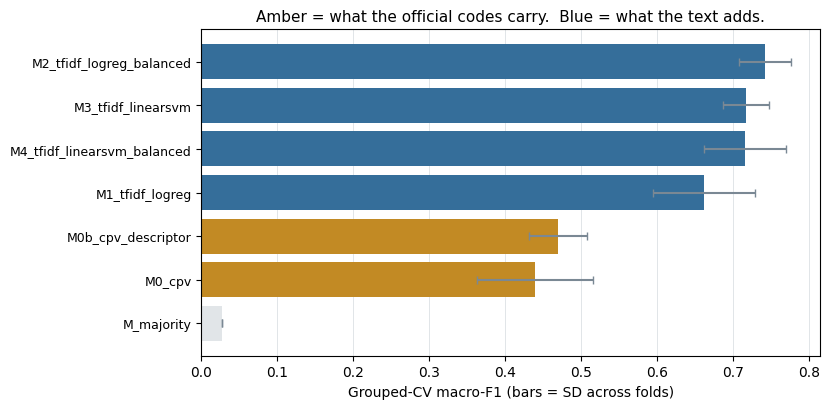

In [12]:
view = comparison[["model", "family", "macro_f1_mean", "macro_f1_sd",
                   "macro_f1_min", "macro_f1_max", "weighted_f1_mean", "accuracy_mean"]]
display(view)

figure, axes = plt.subplots(figsize=(8.4, 4.2))
order = comparison.sort_values("macro_f1_mean")
palette = {"baseline": GRID, "administrative_benchmark": ACCENT, "text": INK}
axes.barh(range(len(order)), order["macro_f1_mean"],
          xerr=order["macro_f1_sd"], capsize=3,
          color=[palette[f] for f in order["family"]], ecolor="#7A8894")
axes.set_yticks(range(len(order)))
axes.set_yticklabels(order["model"], fontsize=9)
axes.set_xlabel("Grouped-CV macro-F1 (bars = SD across folds)")
axes.set_title("Amber = what the official codes carry.  Blue = what the text adds.",
               fontsize=11)
axes.grid(axis="x", color=GRID, linewidth=0.7)
axes.set_axisbelow(True)
figure.tight_layout()
plt.show()

### Result 1 — procurement text carries substantially more than CPV

* **Observation.** Best text model vs best administrative benchmark, on identical
  folds with an identical metric and identical group isolation.
* **What can be concluded.** The business technology class is genuinely present in
  procurement text and genuinely *not* recoverable from the official codes. This is
  the empirical justification for the whole layer.
* **What cannot be concluded.** That CPV is useless — see the per-class table
  below, where CPV *beats* text on `OTHER`, the notices that are not technology
  procurement at all. A clothing purchase is identifiable from its code, not from
  the word "fourniture". The two vocabularies are complements.
* **Implication for Gigalis.** Segment reporting built on CPV divisions alone
  merges cybersecurity, cloud, data and applications into one bucket.

### Quantifying the uncertainty: the family bootstrap

A ratio of the gap to a fold standard deviation is not an interval. Resample
**procurement families** with replacement — two notices in one family are
near-copies, so resampling notices would shrink every interval by pretending the
corpus holds more information than it does. Both models are scored on the *same*
resampled families in each replicate, so the difference is paired.

In [13]:
from boamp_pipeline.technology_models import family_bootstrap

benchmark_model = "M0b_cpv_descriptor"
per_model_ci, paired_ci = family_bootstrap(
    oof, [benchmark_model, "M1_tfidf_logreg", selected]
)
display(per_model_ci)
display(paired_ci)

# Must reproduce what the pipeline stored.
stored_ci = table("bootstrap_macro_f1_ci.csv").set_index("model")
assert np.allclose(
    per_model_ci.set_index("model").loc[stored_ci.index, "macro_f1"], stored_ci["macro_f1"]
)
contrast = paired_ci[(paired_ci.model_a == benchmark_model) & (paired_ci.model_b == selected)].iloc[0]
print(f"\ntext - administrative = {-contrast.observed_difference:.4f} macro-F1")
print(f"95% family-bootstrap CI = [{-contrast.ci_upper:.4f}, {-contrast.ci_lower:.4f}]")
print(f"excludes zero: {contrast.excludes_zero}")

,model,macro_f1,ci_lower,ci_upper,bootstrap_sd,replicates,resampled_unit,families
0,M0b_cpv_descriptor,0.4731,0.4126,0.5259,0.0279,1000,procurement family,459
1,M1_tfidf_logreg,0.6701,0.6072,0.7248,0.0305,1000,procurement family,459
2,M2_tfidf_logreg_balanced,0.7442,0.6819,0.7905,0.0275,1000,procurement family,459


,model_a,model_b,observed_difference,ci_lower,ci_upper,excludes_zero,share_of_replicates_a_higher,replicates
0,M0b_cpv_descriptor,M1_tfidf_logreg,-0.1970,-0.2614,-0.1364,True,0.000,1000
1,M0b_cpv_descriptor,M2_tfidf_logreg_balanced,-0.2711,-0.3403,-0.2009,True,0.000,1000
2,M1_tfidf_logreg,M2_tfidf_logreg_balanced,-0.0741,-0.1283,-0.0223,True,0.001,1000



text - administrative = 0.2711 macro-F1
95% family-bootstrap CI = [0.2009, 0.3403]
excludes zero: True


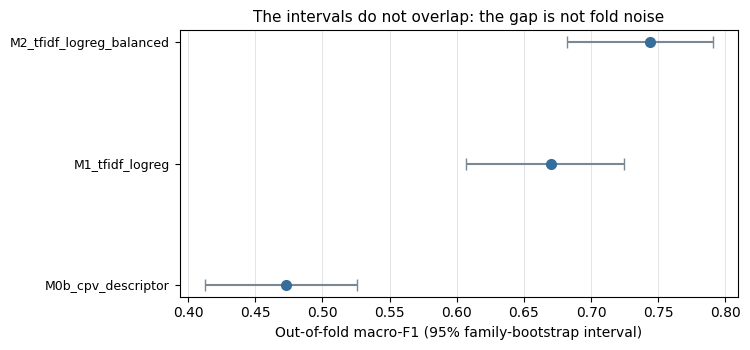

In [14]:
figure, axes = plt.subplots(figsize=(7.6, 3.6))
order = per_model_ci.sort_values("macro_f1")
positions = np.arange(len(order))
axes.errorbar(order["macro_f1"], positions,
              xerr=[order["macro_f1"] - order["ci_lower"], order["ci_upper"] - order["macro_f1"]],
              fmt="o", color=INK, ecolor="#7A8894", capsize=4, markersize=7)
axes.set_yticks(positions)
axes.set_yticklabels(order["model"], fontsize=9)
axes.set_xlabel("Out-of-fold macro-F1 (95% family-bootstrap interval)")
axes.set_title("The intervals do not overlap: the gap is not fold noise", fontsize=11)
axes.grid(axis="x", color=GRID, linewidth=0.7)
axes.set_axisbelow(True)
figure.tight_layout()
plt.show()

### Model selection, under a rule fixed before the numbers were read

The nominal leader is a linear SVM. The **selected** model is the class-weighted
logistic regression, because a probability-emitting model within one paired
standard error of the leader is preferred: at three folds that standard error is
wide, choosing the nominal maximum would be selecting on noise, and SVM decision
margins are not probabilities.

In [15]:
print(json.dumps(decision["selection"]["comparisons"], indent=1))
print(f"\nnominal leader : {decision['selection']['nominal_leader']}")
print(f"selected       : {selected}")
print(f"rule           : {decision['selection']['selection_rule']}")

[
 {
  "model": "M3_tfidf_linearsvm",
  "macro_f1_mean": 0.7169,
  "mean_difference_from_leader": 0.0245,
  "paired_standard_error": 0.0076,
  "within_one_standard_error": false,
  "emits_probabilities": false
 },
 {
  "model": "M4_tfidf_linearsvm_balanced",
  "macro_f1_mean": 0.7157,
  "mean_difference_from_leader": 0.0257,
  "paired_standard_error": 0.0146,
  "within_one_standard_error": false,
  "emits_probabilities": false
 },
 {
  "model": "M1_tfidf_logreg",
  "macro_f1_mean": 0.6617,
  "mean_difference_from_leader": 0.0797,
  "paired_standard_error": 0.0223,
  "within_one_standard_error": false,
  "emits_probabilities": true
 }
]

nominal leader : M2_tfidf_logreg_balanced
selected       : M2_tfidf_logreg_balanced
rule           : highest mean grouped-CV macro-F1; a probability-emitting model within one paired standard error of the leader is preferred over a margin-only model


## 7. Per-class performance — always with support

A class below the support threshold has a printed F1 and **no measured
capability**. This is the difference between reporting `AI` honestly and
overselling it.

In [16]:
from sklearn.metrics import classification_report

selected_oof = oof.loc[oof["model"] == selected]
per_class = table("per_class_metrics.csv")
per_class = per_class.loc[per_class["model"] == selected].set_index("technology")

print(classification_report(selected_oof["true_label"], selected_oof["predicted_label"],
                            labels=list(CLASS_ORDER), zero_division=0))

reliable = per_class[(per_class["support_adequate"]) & (per_class["f1"] >= 0.75)].index.tolist()
weak = per_class[(per_class["support_adequate"]) & (per_class["f1"] < 0.65)].index.tolist()
unmeasurable = per_class[~per_class["support_adequate"]].index.tolist()
print(f"reliable      (F1 >= 0.75, support >= {MIN_RELIABLE_SUPPORT}): {reliable}")
print(f"weak          (F1 <  0.65, support adequate)  : {weak}")
print(f"NOT MEASURABLE (support < {MIN_RELIABLE_SUPPORT})              : {unmeasurable}")

                   precision    recall  f1-score   support

    CLOUD_HOSTING       0.73      0.59      0.66        32
    CYBERSECURITY       0.85      0.72      0.78        54
  NETWORK_TELECOM       0.81      0.84      0.82        81
IT_INFRASTRUCTURE       0.70      0.72      0.71        46
BUSINESS_SOFTWARE       0.80      0.90      0.84        88
          DATA_BI       0.92      0.83      0.87        29
               AI       0.80      0.57      0.67         7
      IT_SERVICES       0.78      0.76      0.77        74
            MIXED       0.48      0.62      0.54        21
    OTHER_DIGITAL       0.65      0.68      0.67        53
            OTHER       0.92      0.80      0.86        15

         accuracy                           0.77       500
        macro avg       0.77      0.73      0.74       500
     weighted avg       0.77      0.77      0.77       500

reliable      (F1 >= 0.75, support >= 10): ['CYBERSECURITY', 'NETWORK_TELECOM', 'BUSINESS_SOFTWARE', 'DATA_BI', 

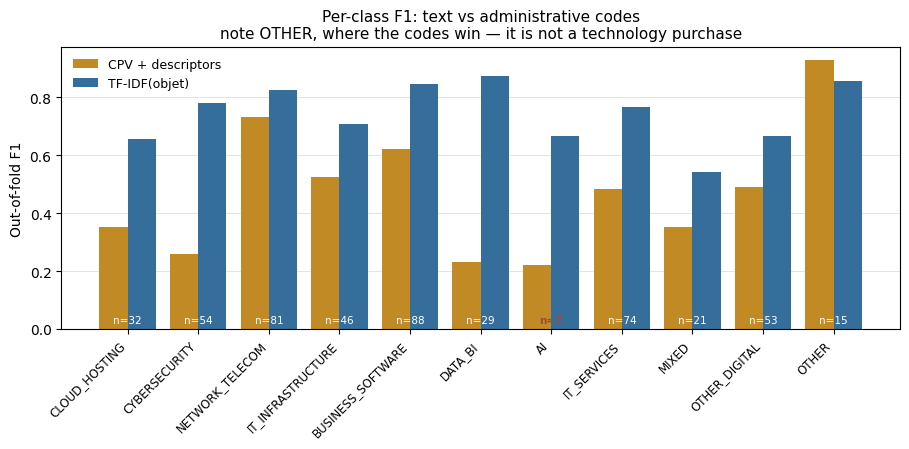

In [17]:
benchmark = table("per_class_metrics.csv")
benchmark = benchmark.loc[benchmark["model"] == "M0b_cpv_descriptor"].set_index("technology")

figure, axes = plt.subplots(figsize=(9.2, 4.6))
positions = np.arange(len(CLASS_ORDER))
axes.bar(positions - 0.2, benchmark.loc[list(CLASS_ORDER), "f1"], width=0.4,
         color=ACCENT, label="CPV + descriptors")
axes.bar(positions + 0.2, per_class.loc[list(CLASS_ORDER), "f1"], width=0.4,
         color=INK, label="TF-IDF(objet)")
for index, label in enumerate(CLASS_ORDER):
    support_value = int(per_class.loc[label, "support"])
    axes.text(index, 0.02, f"n={support_value}", ha="center", fontsize=7.5,
              color="white" if support_value >= MIN_RELIABLE_SUPPORT else RUST,
              weight="bold" if support_value < MIN_RELIABLE_SUPPORT else "normal")
axes.set_xticks(positions)
axes.set_xticklabels(CLASS_ORDER, rotation=45, ha="right", fontsize=8.5)
axes.set_ylabel("Out-of-fold F1")
axes.set_title("Per-class F1: text vs administrative codes\n"
               "note OTHER, where the codes win — it is not a technology purchase",
               fontsize=11)
axes.legend(frameon=False, fontsize=9)
axes.grid(axis="y", color=GRID, linewidth=0.7)
axes.set_axisbelow(True)
figure.tight_layout()
plt.show()

### Confusion structure

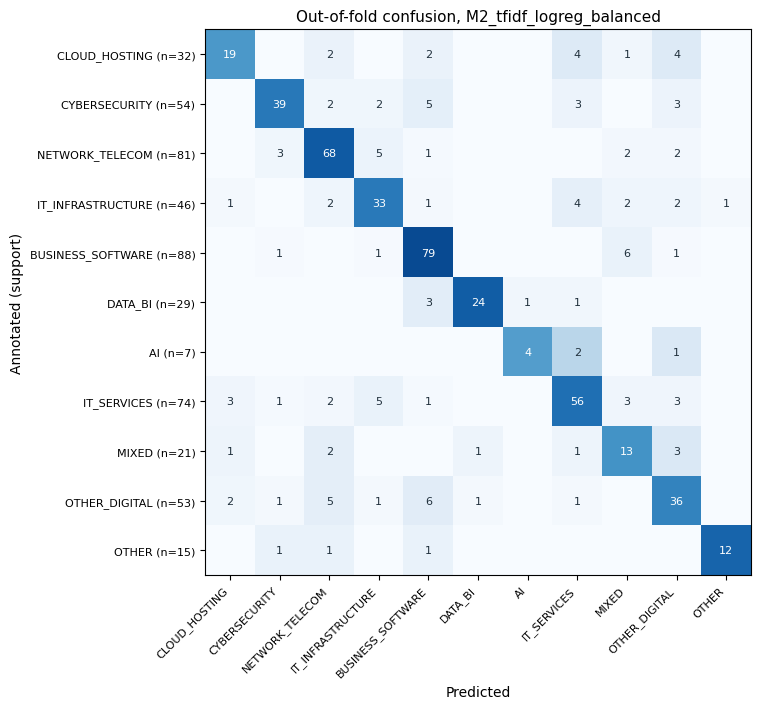

In [18]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(selected_oof["true_label"], selected_oof["predicted_label"],
                          labels=list(CLASS_ORDER))
assert matrix.sum() == len(corpus), "confusion matrix does not cover the corpus"
normalised = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)

figure, axes = plt.subplots(figsize=(8.6, 7.2))
axes.imshow(normalised, cmap="Blues", vmin=0, vmax=1)
axes.set_xticks(range(len(CLASS_ORDER)))
axes.set_yticks(range(len(CLASS_ORDER)))
axes.set_xticklabels(CLASS_ORDER, rotation=45, ha="right", fontsize=8)
axes.set_yticklabels([f"{c} (n={matrix[i].sum()})" for i, c in enumerate(CLASS_ORDER)],
                     fontsize=8)
for i in range(len(CLASS_ORDER)):
    for j in range(len(CLASS_ORDER)):
        if matrix[i, j]:
            axes.text(j, i, matrix[i, j], ha="center", va="center", fontsize=8,
                      color="white" if normalised[i, j] > 0.55 else "#20303C")
axes.set_xlabel("Predicted")
axes.set_ylabel("Annotated (support)")
axes.set_title(f"Out-of-fold confusion, {selected}", fontsize=11)
figure.tight_layout()
plt.show()

## 8. Error analysis

Thirty representative out-of-fold errors, sampled from the largest confusion pairs.
Reading the texts rather than the triage labels, three patterns account for most of
the residual:

1. **`OTHER_DIGITAL` is a heterogeneous residual class** — videosurveillance, RFID,
   videoconference, web maintenance. It borders on three other classes at once and
   appears in most of the largest confusion pairs. A taxonomy-design consequence,
   not a modelling failure.
2. **Website hosting sits on the `CLOUD_HOSTING` boundary.** "Hébergement de sites
   internet" is annotated `CLOUD_HOSTING`, predicted `OTHER_DIGITAL`, repeatedly.
3. **`BUSINESS_SOFTWARE` vs `MIXED` is a property of the procurement.**
   "Fourniture de matériels et logiciels informatiques" *is* mixed.

No label was changed to improve any metric.

In [19]:
display(table("confusion_pairs.csv").head(8))
errors = table("error_analysis.csv")
print(errors["triage_reason"].value_counts().to_string(), "\n")
display(errors[["year", "true_label", "predicted_label", "score_top1",
                "triage_reason", "objet"]].head(14))

,confusion_pair,n,share_of_errors,true_label,predicted_label,true_support,named_adjacent_pair
0,OTHER_DIGITAL -> BUSINESS_SOFTWARE,6,0.0513,OTHER_DIGITAL,BUSINESS_SOFTWARE,53,False
1,BUSINESS_SOFTWARE -> MIXED,6,0.0513,BUSINESS_SOFTWARE,MIXED,88,False
2,OTHER_DIGITAL -> NETWORK_TELECOM,5,0.0427,OTHER_DIGITAL,NETWORK_TELECOM,53,False
3,NETWORK_TELECOM -> IT_INFRASTRUCTURE,5,0.0427,NETWORK_TELECOM,IT_INFRASTRUCTURE,81,False
4,IT_SERVICES -> IT_INFRASTRUCTURE,5,0.0427,IT_SERVICES,IT_INFRASTRUCTURE,74,True
5,CYBERSECURITY -> BUSINESS_SOFTWARE,5,0.0427,CYBERSECURITY,BUSINESS_SOFTWARE,54,False
6,IT_INFRASTRUCTURE -> IT_SERVICES,4,0.0342,IT_INFRASTRUCTURE,IT_SERVICES,46,True
7,CLOUD_HOSTING -> OTHER_DIGITAL,4,0.0342,CLOUD_HOSTING,OTHER_DIGITAL,32,False


triage_reason
model_error                                        16
taxonomy_boundary_ambiguity                         7
genuinely_mixed_or_multi_technology_procurement     4
annotation_inconsistency_in_related_notices         2
insufficient_information_in_objet                   1 



,year,true_label,predicted_label,score_top1,triage_reason,objet
0,2017,OTHER_DIGITAL,BUSINESS_SOFTWARE,0.607049,model_error,"marché d'acquisition, de mise en oeuvre et de maintenance d'un système, incluant des c..."
1,2022,OTHER_DIGITAL,BUSINESS_SOFTWARE,0.282070,model_error,Realisation Et Maintenance D'Un Reseau De Transmission Hertzien Prive Et Videosurveill...
2,2015,OTHER_DIGITAL,BUSINESS_SOFTWARE,0.189898,model_error,"Marché de prestation de service de fourniture, installation et maintenance d'un systèm..."
3,2022,OTHER_DIGITAL,BUSINESS_SOFTWARE,0.157834,model_error,"FOURNITURE, MISE EN SERVICE ET MAINTENANCE D'UNE SOLUTION RFID POUR LA MÉDIATHÈQUE LUC..."
4,2022,BUSINESS_SOFTWARE,MIXED,0.959840,genuinely_mixed_or_multi_technology_procurement,Fourniture de matériels et logiciels informatiques 2022-2025
5,2020,BUSINESS_SOFTWARE,MIXED,0.557741,genuinely_mixed_or_multi_technology_procurement,FOURNITURE DE MATERIELS ET LOGICIELS INFORMATIQUES POUR LE SYNDICATMIXTE MEGALIS BRETAGNE
6,2017,BUSINESS_SOFTWARE,MIXED,0.606600,genuinely_mixed_or_multi_technology_procurement,Fourniture de matériels et de logiciels informatiques pour le SDIS du Calvados
7,2024,BUSINESS_SOFTWARE,MIXED,0.486358,genuinely_mixed_or_multi_technology_procurement,"Fourniture de matériels, composants et logiciels pour systèmes d'information"
8,2021,OTHER_DIGITAL,NETWORK_TELECOM,0.578735,annotation_inconsistency_in_related_notices,2021-12_VISIO_PRESTATION DE SERVICES MANAGES DE VISIOCONFERENCE ET D'AUDIOCONFERENCE
9,2024,OTHER_DIGITAL,NETWORK_TELECOM,0.337700,model_error,"Fourniture, Mise En oeuvre Et Maintenance De L'Extension Du Dispositif De Vidéoprotect..."


## 9. Bias, variance, and what actually limits performance

Every model is scored on its own training fold as well as the held-out fold. The
resubstitution score is not a performance estimate — its only use is the gap,
which separates a model that has memorised its training fold from one that lacks
capacity.

In [20]:
diagnostics = pd.DataFrame([
    {"model": k, **v} for k, v in decision["fit_diagnostics"].items()
]).sort_values("cv_macro_f1", ascending=False)
display(diagnostics)

,model,train_macro_f1,cv_macro_f1,gap,fold_sd
3,M2_tfidf_logreg_balanced,0.9901,0.7414,0.2487,0.0341
4,M3_tfidf_linearsvm,0.9967,0.7169,0.2798,0.0299
5,M4_tfidf_linearsvm_balanced,0.9893,0.7157,0.2735,0.0544
2,M1_tfidf_logreg,1.0000,0.6617,0.3383,0.0673
1,M0b_cpv_descriptor,0.8198,0.4694,0.3503,0.0376
0,M0_cpv,0.7562,0.4388,0.3174,0.0764


The curve below subsamples **families**, not rows, so a subsample never holds
half of a related-notice group.

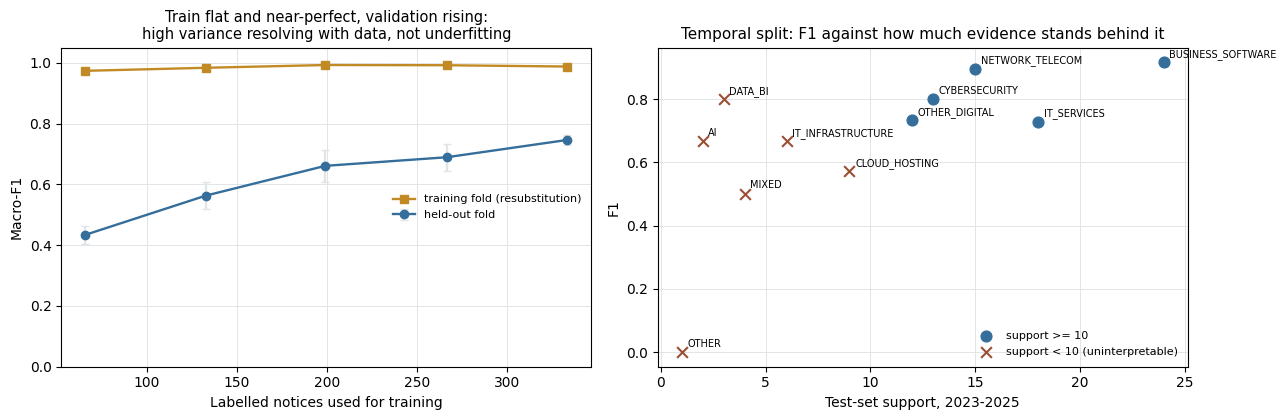

train 2015-2022 (n=393)  ->  test 2023-2025 (n=107)
4 families straddling the boundary were assigned to training in full — costs test rows, cannot flatter
macro-F1 all 11 classes            : 0.6617
macro-F1 adequate-support classes  : 0.8148


In [21]:
curve = table("learning_curve.csv")
temporal = table("temporal_validation_metrics.csv").iloc[0]

figure, (left, right) = plt.subplots(1, 2, figsize=(13.0, 4.3))
left.plot(curve["mean_train_rows"], curve["train_macro_f1_mean"], marker="s",
          color=ACCENT, linewidth=1.7, label="training fold (resubstitution)")
left.errorbar(curve["mean_train_rows"], curve["macro_f1_mean"], yerr=curve["macro_f1_sd"],
              marker="o", color=INK, ecolor=GRID, capsize=3, linewidth=1.7,
              label="held-out fold")
left.set_ylim(0, 1.05)
left.set_xlabel("Labelled notices used for training")
left.set_ylabel("Macro-F1")
left.set_title("Train flat and near-perfect, validation rising:\nhigh variance resolving with data, not underfitting", fontsize=10.5)
left.legend(frameon=False, fontsize=8, loc="center right")
left.grid(color=GRID, linewidth=0.7)
left.set_axisbelow(True)

per_class_temporal = table("temporal_validation_per_class.csv")
adequate = per_class_temporal["support"] >= MIN_RELIABLE_SUPPORT
right.scatter(per_class_temporal.loc[adequate, "support"],
              per_class_temporal.loc[adequate, "f1"], color=INK, s=60, label="support >= 10")
right.scatter(per_class_temporal.loc[~adequate, "support"],
              per_class_temporal.loc[~adequate, "f1"], color=RUST, s=60,
              marker="x", label="support < 10 (uninterpretable)")
for row in per_class_temporal.itertuples():
    right.annotate(row.technology, (row.support, row.f1), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
right.set_xlabel("Test-set support, 2023-2025")
right.set_ylabel("F1")
right.set_title("Temporal split: F1 against how much evidence stands behind it",
                fontsize=11)
right.legend(frameon=False, fontsize=8)
right.grid(color=GRID, linewidth=0.7)
right.set_axisbelow(True)
figure.tight_layout()
plt.show()

print(f"train {temporal['train_years']} (n={temporal['n_train']})  ->  "
      f"test {temporal['test_years']} (n={temporal['n_test']})")
print(f"{temporal['groups_straddling_boundary_moved_to_train']} families straddling the "
      "boundary were assigned to training in full — costs test rows, cannot flatter")
print(f"macro-F1 all 11 classes            : {temporal['macro_f1']}")
print(f"macro-F1 adequate-support classes  : {temporal['macro_f1_adequate_support_classes']}")

**Result 2 — performance holds on recent notices, for the classes that can be
measured.** The all-class figure falls because several of eleven classes have fewer
than ten recent test observations; restricted to the classes with adequate support
it is at or above the primary estimate. This is no clear evidence of temporal
deterioration — not a demonstration that none exists. Nothing can be said about
recent `AI`, `OTHER` or `MIXED`.

**Result 3 — high variance, not underfitting.** Training macro-F1 sits near 0.99 at
every training size while validation climbs; the gap closes monotonically as
families are added. The representation does not lack capacity, so a *richer* one —
word plus character n-grams — was considered and **not tested**: it adds capacity,
the opposite of what this diagnosis calls for. The regularisation path that would
address variance was already searched (`C` spans two orders of magnitude in the
inner CV, and the selected values are interior to that range).

The binding constraint is the number of independent labelled families. How much
further the curve would rise is not identified by five points, and no minimum
sample size is implied.

## 10. Was a transformer justified?

The gate was written down **before** the classical results were read.

In [22]:
gate = decision["camembert_gate"]
print(gate["gate_specification"], "\n")
for condition, value in gate["conditions"].items():
    print(f"  {'MET    ' if value else 'not met'}  {condition}")
print(f"\nselected model macro-F1: {gate['selected_model_macro_f1']}")
print(f"DECISION: {gate['decision']}")

A transformer is tested only if the frozen classical model is materially inadequate (mean grouped-CV macro-F1 < 0.55) AND fewer than half of its errors are attributable to label ambiguity or missing information in the text, which no encoder can supply. 

  not met  classical_macro_f1_below_0_55
  not met  text_gain_over_administrative_benchmark_below_0_05
  MET      majority_of_errors_are_not_label_or_information_limited

selected model macro-F1: 0.7414
DECISION: do not test CamemBERT; keep the classical model


CamemBERT was **not tested** — it was not run, because the criterion for running it
was not met. That is different from testing it and discarding it. Adding it would
have brought a large dependency and an opaque model to a component whose errors are
concentrated on definitional boundaries rather than semantics.

## 11. Confidence — and why it is not a probability at face value

The deployed model emits Platt-scaled class probabilities, calibrated on labelled
data only, inside the same grouped splits. Calibration was adopted under a
pre-specified rule.

It is still **conservative**: observed accuracy exceeds stated confidence in every
bin above 0.3. Reweighting eleven classes with `class_weight='balanced'` flattens
the probability simplex and Platt scaling only partly undoes it.

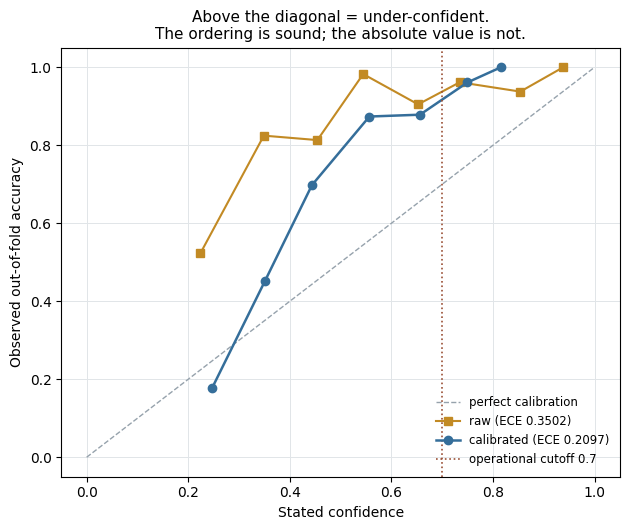

,bin,n,observed_accuracy,mean_confidence,calibration_gap
8,"[0.0, 0.3)",45,0.1778,0.2471,-0.0693
9,"[0.3, 0.4)",73,0.4521,0.3511,0.1010
10,"[0.4, 0.5)",86,0.6977,0.4435,0.2542
11,"[0.5, 0.6)",87,0.8736,0.5566,0.3169
12,"[0.6, 0.7)",115,0.8783,0.6562,0.2220
13,"[0.7, 0.8)",77,0.9610,0.7496,0.2114
14,"[0.8, 0.9)",17,1.0000,0.8157,0.1843


at the 0.7 cutoff: out-of-fold accuracy 0.9556 on 9% of notices, against 0.7495 below it


In [23]:
config = load_json("final_model_config.json")
reliability = table("confidence_reliability_oof.csv")
calibrated_bins = reliability.loc[reliability["variant"] == "calibrated"]
raw_bins = reliability.loc[reliability["variant"] == "raw"]

figure, axes = plt.subplots(figsize=(6.4, 5.4))
axes.plot([0, 1], [0, 1], color="#96A2AC", linestyle="--", linewidth=1,
          label="perfect calibration")
axes.plot(raw_bins["mean_confidence"], raw_bins["observed_accuracy"], marker="s",
          color=ACCENT, linewidth=1.5, label="raw (ECE "
          f"{config['calibration']['variants']['raw']['expected_calibration_error']})")
axes.plot(calibrated_bins["mean_confidence"], calibrated_bins["observed_accuracy"],
          marker="o", color=INK, linewidth=1.8, label="calibrated (ECE "
          f"{config['calibration']['variants']['calibrated']['expected_calibration_error']})")
axes.axvline(CONFIDENCE_CUTOFF, color=RUST, linestyle=":", linewidth=1.2,
             label=f"operational cutoff {CONFIDENCE_CUTOFF}")
axes.set_xlabel("Stated confidence")
axes.set_ylabel("Observed out-of-fold accuracy")
axes.set_title("Above the diagonal = under-confident.\nThe ordering is sound; the "
               "absolute value is not.", fontsize=11)
axes.legend(frameon=False, fontsize=8.5, loc="lower right")
axes.grid(color=GRID, linewidth=0.7)
axes.set_axisbelow(True)
figure.tight_layout()
plt.show()

display(calibrated_bins[["bin", "n", "observed_accuracy", "mean_confidence",
                         "calibration_gap"]])
confidence = config["confidence"]
print(f"at the {CONFIDENCE_CUTOFF} cutoff: out-of-fold accuracy "
      f"{confidence['oof_accuracy_at_or_above_cutoff']} on "
      f"{confidence['oof_share_at_or_above_cutoff']:.0%} of notices, against "
      f"{confidence['oof_accuracy_below_cutoff']} below it")

## 12. Deployment to the study cohort

The classifier was trained on **notices**; the study analyses **episodes**. Each
cohort episode is represented by the `objet` of its earliest competition notice, or
its earliest notice when award-only — the same origin rule the episode layer
already uses. Concatenating an episode's notices would feed the model documents
several times longer than anything it saw in training.

The frozen model is **loaded, not refitted**, so what is inspected here is exactly
what scored the cohort.

In [24]:
import joblib

model = joblib.load(TECHNOLOGY / "technology_classifier.joblib")
predictions = table("episode_technology_predictions.csv")

assert predictions["episode_id"].is_unique
assert len(predictions) == 3800
print(f"{type(model).__name__} over {config['specification']}")
print(f"deployment text median {int(predictions['objet_word_count'].median())} words "
      f"vs training median {int(corpus['text_word_count'].median())} words\n")

# The loaded model must reproduce the stored predictions exactly.
sample = predictions.head(200)
reproduced = model.predict(sample["objet_used_for_prediction"].map(normalize_objet))
assert (reproduced == sample["predicted_technology"]).all()
print("loaded model reproduces the stored predictions")
display(predictions[["episode_id", "existing_cpv_segment", "predicted_technology",
                     "confidence", "confidence_status", "objet_used_for_prediction"]].head(6))

Pipeline over M2_tfidf_logreg_balanced
deployment text median 15 words vs training median 14 words

loaded model reproduces the stored predictions


,episode_id,existing_cpv_segment,predicted_technology,confidence,confidence_status,objet_used_for_prediction
0,EP-608c7e6c3b9c175d,CPV-48,BUSINESS_SOFTWARE,0.196574,low,evolution du systeme de gestion operationnelle au profit du SDIS à Coulaines
1,EP-d042579ff07fb8f9,CPV-35,NETWORK_TELECOM,0.225683,low,"prestation de fiabilisation, pérennisation des radars de veille Drbv21-A et maintien e..."
2,EP-8231e5f0e0969574,CPV-48,BUSINESS_SOFTWARE,0.424362,low,fourniture de logiciels ibm-lotus et de prestations d'assistance technique associées p...
3,EP-48e4f9432f605e3e,CPV-48,MIXED,0.251545,low,refonte globale de l'infrastructure serveurs et stockages informatiques à Bouguenais
4,EP-f051d09c0330a714,CPV-72,IT_SERVICES,0.460628,low,mission de programmation et d'assistance à maîtrise d'ouvrage pour la construction de ...
5,EP-9a5d50043ce3313e,CPV-72,OTHER_DIGITAL,0.179027,low,"fourniture, mise en oeuvre et exploitation d'un pass touristique pour 1, 2 ou 3 jours ..."


### Composition, and the confidence coverage diagnostic

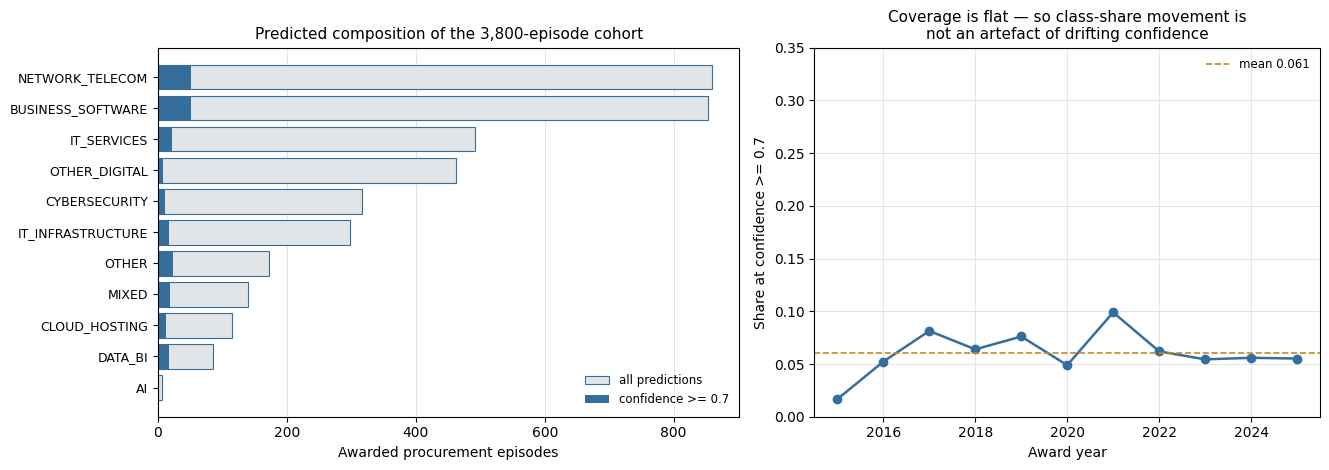

235 of 3,800 predictions (6.2%) clear the cutoff. None is discarded — low confidence sets a flag only.


,cutoff,retained,rejected,retention_rate,min_year_retention
0,0.5,648,3152,0.1705,0.1037
1,0.6,412,3388,0.1084,0.0502
2,0.7,235,3565,0.0618,0.0167
3,0.8,123,3677,0.0324,0.0067
4,0.9,28,3772,0.0074,0.0028


In [25]:
composition = table("technology_composition.csv")
coverage = table("confidence_coverage_by_year.csv")

figure, (left, right) = plt.subplots(1, 2, figsize=(13.4, 4.8),
                                     gridspec_kw={"width_ratios": [1.15, 1]})
order = composition.loc[composition["n"] > 0].sort_values("n")
positions = np.arange(len(order))
left.barh(positions, order["n"], color=GRID, edgecolor=INK, linewidth=0.8,
          label="all predictions")
left.barh(positions, order["high_confidence_n"], color=INK,
          label=f"confidence >= {CONFIDENCE_CUTOFF}")
left.set_yticks(positions)
left.set_yticklabels(order["technology"], fontsize=9)
left.set_xlabel("Awarded procurement episodes")
left.set_title("Predicted composition of the 3,800-episode cohort", fontsize=11)
left.legend(frameon=False, fontsize=8.5, loc="lower right")
left.grid(axis="x", color=GRID, linewidth=0.7)
left.set_axisbelow(True)

right.plot(coverage["award_year"], coverage["coverage"], marker="o", color=INK, linewidth=1.8)
right.axhline(coverage["coverage"].mean(), color=ACCENT, linestyle="--", linewidth=1.2,
              label=f"mean {coverage['coverage'].mean():.3f}")
right.set_ylim(0, 0.35)
right.set_xlabel("Award year")
right.set_ylabel(f"Share at confidence >= {CONFIDENCE_CUTOFF}")
right.set_title("Coverage is flat — so class-share movement is\nnot an artefact of "
                "drifting confidence", fontsize=11)
right.legend(frameon=False, fontsize=8.5)
right.grid(color=GRID, linewidth=0.7)
right.set_axisbelow(True)
figure.tight_layout()
plt.show()

high = (predictions["confidence_status"] == "high").sum()
print(f"{high:,} of {len(predictions):,} predictions ({high / len(predictions):.1%}) "
      f"clear the cutoff. None is discarded — low confidence sets a flag only.")
display(table("confidence_cutoff_sweep.csv"))

### Result 4 — the taxonomy cuts across the CPV segmentation

If the taxonomy merely renamed CPV, each column below would have one dark cell.
It does not.

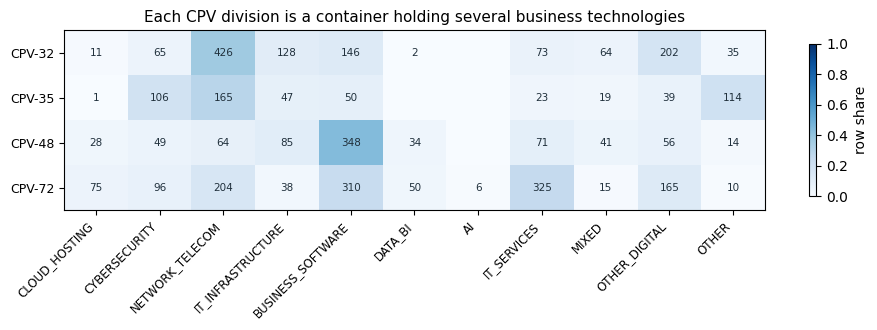

mean CPV-segment purity : 0.3385
mean technology purity  : 0.5563


In [26]:
cross = pd.read_csv(TECHNOLOGY / "technology_cpv_crosswalk.csv", index_col=0)
evidence = load_json("technology_evidence_summary.json")
shares = cross.div(cross.sum(axis=1), axis=0)

figure, axes = plt.subplots(figsize=(9.6, 3.4))
image = axes.imshow(shares.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes.set_xticks(range(shares.shape[1]))
axes.set_xticklabels(shares.columns, rotation=45, ha="right", fontsize=8.5)
axes.set_yticks(range(len(shares)))
axes.set_yticklabels(shares.index, fontsize=9)
for i in range(shares.shape[0]):
    for j in range(shares.shape[1]):
        if cross.iloc[i, j]:
            axes.text(j, i, cross.iloc[i, j], ha="center", va="center", fontsize=7.5,
                      color="white" if shares.iloc[i, j] > 0.5 else "#20303C")
axes.set_title("Each CPV division is a container holding several business technologies",
               fontsize=11)
figure.colorbar(image, ax=axes, shrink=0.85, label="row share")
figure.tight_layout()
plt.show()

print(f"mean CPV-segment purity : {evidence['crosswalk']['mean_segment_purity']}")
print(f"mean technology purity  : {evidence['crosswalk']['mean_technology_purity']}")

## 13. Downstream enrichment, behind two gates

A class enters the substantive analysis only by clearing **both** gates, fixed
before any curve was fitted.

**Gate A — classifier evidence.** Does the label mean anything? A class the
classifier cannot separate produces a downstream group that is a *mixture* of
technologies, and a curve fitted to it estimates the mixture. Requires a
substantive class, reference support ≥ 10, and out-of-fold F1 ≥ 0.65.

Fallback classes are excluded outright. `OTHER_DIGITAL` holds videosurveillance,
RFID and web maintenance at once; placing that bucket beside cybersecurity in a
"comparison across technologies" invites the reader to read the contrast as a
technology effect when part of it is the bucket's heterogeneity.

**Gate B — statistical support.** Can the sample carry an estimate? A perfectly
classified class with six episodes and no events cannot.

In [27]:
gate_a = table("technology_classifier_gate.csv")
support_table = table("technology_survival_support.csv")
horizons = table("technology_survival_summary.csv")
trend = table("technology_trend_summary.csv")

display(gate_a[["technology", "reference_support", "precision", "recall", "f1",
                "passes_classifier_gate", "classifier_gate_reason"]])
display(support_table[["technology", "cv_f1", "episodes", "events",
                       "passes_classifier_gate", "passes_statistical_gate",
                       "meets_support_gate", "exclusion_reason"]])
print("analysed:", evidence["survival"]["eligible_classes"])

,technology,reference_support,precision,recall,f1,passes_classifier_gate,classifier_gate_reason
0,CLOUD_HOSTING,32,0.7308,0.5938,0.6552,True,passes
1,CYBERSECURITY,54,0.8478,0.7222,0.7800,True,passes
2,NETWORK_TELECOM,81,0.8095,0.8395,0.8242,True,passes
3,IT_INFRASTRUCTURE,46,0.7021,0.7174,0.7097,True,passes
4,BUSINESS_SOFTWARE,88,0.7980,0.8977,0.8449,True,passes
5,DATA_BI,29,0.9231,0.8276,0.8727,True,passes
6,AI,7,0.8000,0.5714,0.6667,False,reference support below 10
7,IT_SERVICES,74,0.7778,0.7568,0.7671,True,passes
8,MIXED,21,0.4815,0.6190,0.5417,False,"fallback class, not a substantive technology"
9,OTHER_DIGITAL,53,0.6545,0.6792,0.6667,False,"fallback class, not a substantive technology"


,technology,cv_f1,episodes,events,passes_classifier_gate,passes_statistical_gate,meets_support_gate,exclusion_reason
0,CLOUD_HOSTING,0.6552,115,11,True,False,False,episodes < 100 or events < 20
1,CYBERSECURITY,0.7800,316,60,True,True,True,NaN
2,NETWORK_TELECOM,0.8242,859,140,True,True,True,NaN
3,IT_INFRASTRUCTURE,0.7097,298,38,True,True,True,NaN
4,BUSINESS_SOFTWARE,0.8449,854,106,True,True,True,NaN
5,DATA_BI,0.8727,86,15,True,False,False,episodes < 100 or events < 20
6,AI,0.6667,6,0,False,False,False,reference support below 10
7,IT_SERVICES,0.7671,492,72,True,True,True,NaN
8,MIXED,0.5417,139,32,False,True,False,"fallback class, not a substantive technology"
9,OTHER_DIGITAL,0.6667,462,44,False,True,False,"fallback class, not a substantive technology"


analysed: ['CYBERSECURITY', 'NETWORK_TELECOM', 'IT_INFRASTRUCTURE', 'BUSINESS_SOFTWARE', 'IT_SERVICES']


**This gate changes the headline.** Running the same log-rank test with the
fallback classes included gives a materially different p-value — the residual
buckets dilute a comparison that is supposed to be about technologies. The cell
below shows both, which is why Gate A exists rather than being assumed.

In [28]:
from lifelines.statistics import multivariate_logrank_test

survival_all = pd.read_parquet(
    PROJECT_ROOT / "data/processed/boamp/survival_dataset.parquet",
    columns=["episode_id", "event", "duration_days"],
)
merged_all = survival_all.merge(
    predictions[["episode_id", "predicted_technology"]], on="episode_id")
merged_all["t_months"] = np.maximum(merged_all["duration_days"], 1) / 30.4375

gated = support_table.loc[support_table["meets_support_gate"], "technology"].tolist()
statistical_only = support_table.loc[
    support_table["passes_statistical_gate"], "technology"].tolist()

for label, classes in [("both gates (substantive only)", gated),
                       ("statistical support only (incl. fallback)", statistical_only)]:
    block = merged_all[merged_all["predicted_technology"].isin(classes)]
    test = multivariate_logrank_test(
        block["t_months"], block["predicted_technology"], block["event"])
    print(f"{label:44s} k={len(classes)}  events={int(block['event'].sum()):3d}  "
          f"p={test.p_value:.4f}")

both gates (substantive only)                k=5  events=416  p=0.0363
statistical support only (incl. fallback)    k=8  events=518  p=0.0001


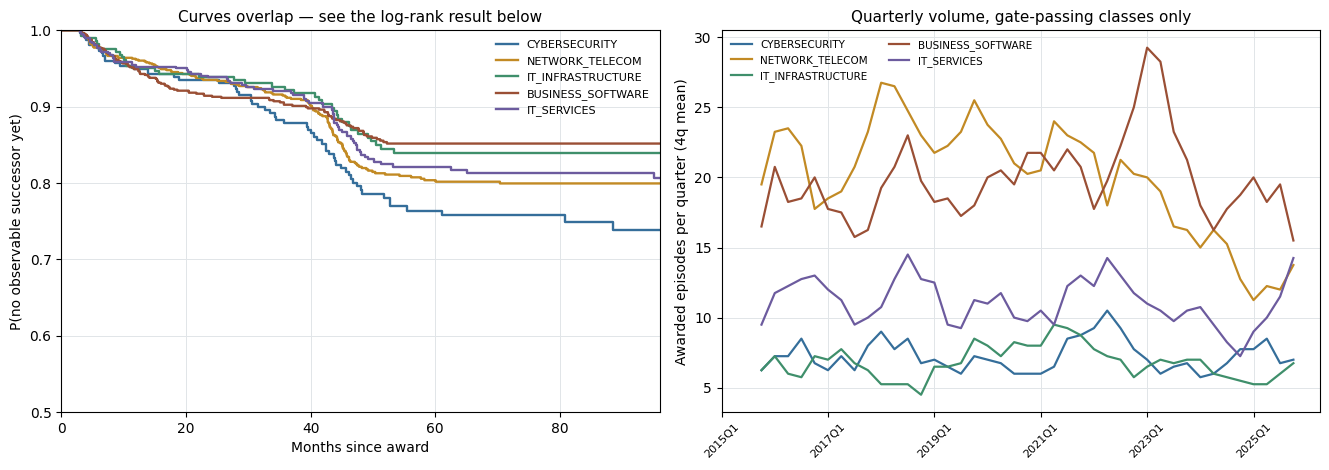

log-rank across 5 classes: statistic 10.2579, p = 0.0363 on 416 events


,technology,horizon_months,successor_probability,survival_probability,episodes,events,at_risk_at_horizon
1,CYBERSECURITY,24,0.0646,0.9354,316,60,246
4,NETWORK_TELECOM,24,0.0649,0.9351,859,140,716
7,IT_INFRASTRUCTURE,24,0.0611,0.9389,298,38,239
10,BUSINESS_SOFTWARE,24,0.0857,0.9143,854,106,673
13,IT_SERVICES,24,0.0617,0.9383,492,72,393



One slope per class is one test per class, so raw p-values are shown
beside Holm (family-wise) and Benjamini-Hochberg (FDR) adjustments:


,technology,episodes,slope_episodes_per_quarter,slope_p_value,p_holm,p_bh,n_tests,direction
0,CYBERSECURITY,316,0.0245,0.4857,1.0000,0.6071,5,no linear trend detected
1,NETWORK_TELECOM,859,-0.1668,0.0563,0.2815,0.0563,5,no linear trend detected
2,IT_INFRASTRUCTURE,298,0.0078,0.8116,1.0000,1.0000,5,no linear trend detected
3,BUSINESS_SOFTWARE,854,0.0440,0.5604,1.0000,0.9340,5,no linear trend detected
4,IT_SERVICES,492,0.0021,0.9617,1.0000,1.0000,5,no linear trend detected


In [29]:
from lifelines import KaplanMeierFitter

survival = pd.read_parquet(PROJECT_ROOT / "data/processed/boamp/survival_dataset.parquet",
                           columns=["episode_id", "event", "duration_days"])
merged = survival.merge(predictions[["episode_id", "predicted_technology"]], on="episode_id")
merged["t_months"] = np.maximum(merged["duration_days"], 1) / 30.4375
eligible = support_table.loc[support_table["meets_support_gate"], "technology"].tolist()

figure, (left, right) = plt.subplots(1, 2, figsize=(13.4, 4.8))
palette = [INK, ACCENT, GREEN, RUST, "#6C5B9E", "#2F7D8C", "#8C6D3F"]
for index, label in enumerate(eligible):
    block = merged.loc[merged["predicted_technology"] == label]
    KaplanMeierFitter().fit(block["t_months"], block["event"], label=label).plot_survival_function(
        ax=left, ci_show=False, color=palette[index % len(palette)], linewidth=1.7)
left.set_xlim(0, 96)
left.set_ylim(0.5, 1.0)
left.set_xlabel("Months since award")
left.set_ylabel("P(no observable successor yet)")
left.set_title("Curves overlap — see the log-rank result below", fontsize=11)
left.legend(frameon=False, fontsize=8)
left.grid(color=GRID, linewidth=0.7)
left.set_axisbelow(True)

quarterly = pd.read_csv(TECHNOLOGY / "technology_quarterly_counts.csv", index_col=0)
for index, label in enumerate(trend["technology"]):
    right.plot(range(len(quarterly)), quarterly[label].rolling(4).mean(),
               color=palette[index % len(palette)], linewidth=1.6, label=label)
right.set_xticks(range(0, len(quarterly), 8))
right.set_xticklabels(quarterly.index[::8], rotation=45, fontsize=8)
right.set_ylabel("Awarded episodes per quarter (4q mean)")
right.set_title("Quarterly volume, gate-passing classes only", fontsize=11)
right.legend(frameon=False, fontsize=7.5, ncol=2)
right.grid(color=GRID, linewidth=0.7)
right.set_axisbelow(True)
figure.tight_layout()
plt.show()

print(f"log-rank across {len(eligible)} classes: statistic "
      f"{evidence['survival']['logrank_statistic']}, p = "
      f"{evidence['survival']['logrank_p_value']} on "
      f"{evidence['survival']['logrank_events']} events")
display(horizons.loc[horizons["horizon_months"] == 24])
print("\nOne slope per class is one test per class, so raw p-values are shown"
      "\nbeside Holm (family-wise) and Benjamini-Hochberg (FDR) adjustments:")
display(trend[["technology", "episodes", "slope_episodes_per_quarter",
               "slope_p_value", "p_holm", "p_bh", "n_tests", "direction"]])

### Would filtering to high confidence change the trend?

The original brief contemplated dropping predictions below 0.70 before estimating
any trend. That is only defensible if what remains is still a series.

In [30]:
sensitivity = table("technology_trend_confidence_sensitivity.csv")
display(sensitivity[["technology", "arm", "episodes", "zero_quarters",
                     "median_per_quarter", "slope_episodes_per_quarter", "slope_p_value"]])

filtered = sensitivity[sensitivity.arm == "confidence_ge_0.70"]
print(f"filtered arm: {filtered['episodes'].min()}-{filtered['episodes'].max()} episodes "
      f"per class, {filtered['zero_quarters'].min()}-{filtered['zero_quarters'].max()} "
      f"empty quarters out of {int(sensitivity['quarters'].iloc[0])}")
spurious = filtered[(filtered.slope_p_value < 0.05)]
if len(spurious):
    print(f"note: {list(spurious.technology)} reaches nominal significance ONLY in the "
          "sparse arm -- what fitting a line to a mostly-empty series produces")

,technology,arm,episodes,zero_quarters,median_per_quarter,slope_episodes_per_quarter,slope_p_value
0,CYBERSECURITY,all_predictions,316,0,7.0,0.0245,0.4857
1,CYBERSECURITY,confidence_ge_0.70,11,33,0.0,-0.0056,0.2896
2,NETWORK_TELECOM,all_predictions,859,0,19.0,-0.1668,0.0563
3,NETWORK_TELECOM,confidence_ge_0.70,52,16,1.0,-0.0070,0.6437
4,IT_INFRASTRUCTURE,all_predictions,298,0,7.0,0.0078,0.8116
5,IT_INFRASTRUCTURE,confidence_ge_0.70,17,33,0.0,-0.0077,0.4156
6,BUSINESS_SOFTWARE,all_predictions,854,0,20.0,0.0440,0.5604
7,BUSINESS_SOFTWARE,confidence_ge_0.70,52,15,1.0,0.0103,0.4305
8,IT_SERVICES,all_predictions,492,0,11.0,0.0021,0.9617
9,IT_SERVICES,confidence_ge_0.70,21,25,0.0,0.0147,0.0339


filtered arm: 11-52 episodes per class, 15-33 empty quarters out of 44
note: ['IT_SERVICES'] reaches nominal significance ONLY in the sparse arm -- what fitting a line to a mostly-empty series produces


**Result 4 — a difference in observable re-procurement timing is detected across
the analysed substantive classes.** The omnibus log-rank test reaches the 5% level
on the five classes clearing both gates. It says the classes are not all alike; it
does not identify which pair drives the result, and no pairwise comparison is
offered. Three things sit between this and a statement about technology: the event
is an *observable successor procurement*, not a confirmed renewal; the labels are
predictions carrying the error rate in section 7; and nothing is adjusted for buyer
type, contract size or procedure.

**Result 5 — no technology series shows a linear trend surviving multiplicity
adjustment.** Five slopes were tested simultaneously. The smallest raw p-value does
not reach the 5% level even before adjustment. PELT breakpoints, HMM regimes and
stationarity tests stay on the CPV reference series in `TREND_ANALYSIS_REPORT.md`:
running them across derived technology series would multiply tests without
answering a new question.

## 14. What this establishes, and what it does not

**Established.**

- Procurement text carries the business technology class; the official codes do
  not. Measured on identical folds with group isolation.
- The high-volume classes are separated out of sample and on recent notices.
- The taxonomy cuts across the CPV segmentation rather than reproducing it.
- Every cohort episode carries one prediction and a confidence, and confidence
  coverage does not drift over time.

**Not established.**

- Any capability on `AI`. Seven annotated notices; the class is a rare-class
  limitation, not a measured result.
- Exact class volumes in the cohort. A class with a cross-validated recall near
  0.70 has a genuinely uncertain true volume and none is offered here.
- That a stated confidence is a probability of correctness at face value.
- Any causal reading of the technology-level survival or trend comparison.
- **Label reliability.** The corpus was delivered as one labelled file with no
  annotator identifier and no second pass, so no Cohen's kappa can be computed. The
  internship guide's two-annotator L2 design is not met, and the three documented
  internal inconsistencies are the only direct evidence about label stability.

Predicted labels are predictions. Every downstream technology-level number inherits
the classifier's error rate without propagating its uncertainty.

## 15. Reproducing this

```bash
# the whole layer, four ordered stages, about one minute
PYTHONPATH=. python3 scripts/build_technology_taxonomy.py --force

# one stage while iterating
PYTHONPATH=. python3 scripts/build_technology_taxonomy.py --stage models --force

# this notebook
PYTHONPATH=. jupyter nbconvert --execute --to notebook --inplace \
    notebooks/15_technology_taxonomy_classification.ipynb

PYTHONPATH=. pytest -q tests/test_technology_taxonomy.py
```

All analysis lives in `boamp_pipeline/technology_taxonomy.py`,
`boamp_pipeline/technology_models.py` and
`boamp_pipeline/technology_evidence.py`. The script is orchestration only, so the
cells above run the same code the pipeline runs.